In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from torch.utils.data import Dataset, DataLoader

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device :", device)

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))

Device : cuda
GPU : NVIDIA GeForce RTX 3060 Ti


In [3]:
df = pd.read_csv("../output/dataset_preprocessing.csv")

print(df.shape)

df.head()

(20807, 9)

,label,author,comment,id,channel,title,cleaning,casefolding,hasil_preprocessing
0,1,Abatistalima-b4t,"AЕR𝐎𝟴𝟴 gua main dikit aja, saldo lngsg nambah",CIUnp8NMw8w,Deddy Corbuzier,TERNYATA ARAFAH PERNAH PACARAN SAMA ATE‼️😅 - P...,AERO88 gua main dikit aja saldo lngsg nambah,aero88 gua main dikit aja saldo lngsg nambah,aero88 gua main dikit aja saldo lngsg nambah
1,1,AbdulkadirMustafa-z4t,Sebelumnya bermain di tempat lain terasa kuran...,CIUnp8NMw8w,Deddy Corbuzier,TERNYATA ARAFAH PERNAH PACARAN SAMA ATE‼️😅 - P...,Sebelumnya bermain di tempat lain terasa kuran...,sebelumnya bermain di tempat lain terasa kuran...,sebelumnya bermain di tempat lain terasa kuran...
2,1,abdullaGodgift-m1w,AЕR𝐎𝟴𝟴 aku sih gmpang bgt dapet WEDEY gede dsini,CIUnp8NMw8w,Deddy Corbuzier,TERNYATA ARAFAH PERNAH PACARAN SAMA ATE‼️😅 - P...,AERO88 aku sih gmpang bgt dapet WEDEY gede dsini,aero88 aku sih gmpang bgt dapet wedey gede dsini,aero88 aku sih gmpang bgt dapet wedey gede dsini
3,1,AbdullahFABIAN-i2m,"AЕR𝐎𝟴𝟴 gua cba bentar, eh lgnsung dapet jackpot",CIUnp8NMw8w,Deddy Corbuzier,TERNYATA ARAFAH PERNAH PACARAN SAMA ATE‼️😅 - P...,AERO88 gua cba bentar eh lgnsung dapet jackpot,aero88 gua cba bentar eh lgnsung dapet jackpot,aero88 gua cba bentar eh lgnsung dapet jackpot
4,1,Abergerontorres-s3d,"AЕR𝐎𝟴𝟴 aku cba maen, malah jackpot gede",CIUnp8NMw8w,Deddy Corbuzier,TERNYATA ARAFAH PERNAH PACARAN SAMA ATE‼️😅 - P...,AERO88 aku cba maen malah jackpot gede,aero88 aku cba maen malah jackpot gede,aero88 aku cba maen malah jackpot gede


In [4]:
from transformers import AutoTokenizer

MODEL_PATH = "../model/indobert_best"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

In [5]:
import pandas as pd

df = pd.read_csv("../output/dataset_preprocessing.csv")

print(df.shape)
print(df.columns)

(20807, 9)
Index(['label', 'author', 'comment', 'id', 'channel', 'title', 'cleaning',
       'casefolding', 'hasil_preprocessing'],
      dtype='str')


In [6]:
import pandas as pd

df = pd.read_csv("../output/dataset_preprocessing.csv")

df = df.dropna(subset=["hasil_preprocessing"])

print(df.shape)

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("Train :", len(train_df))
print("Validation :", len(valid_df))
print("Test :", len(test_df))

(20705, 9)


Train : 16564
Validation : 2070
Test : 2071


In [7]:
MODEL_PATH = "../model/indobert_best"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_PATH
)

model.to(device)

model.eval()

print("Model berhasil dimuat.")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model berhasil dimuat.


In [8]:
class IndoBERTDataset(Dataset):

    def __init__(self, texts, labels, tokenizer, max_length):

        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):

        return len(self.texts)

    def __getitem__(self, idx):

        encoding = self.tokenizer(

            str(self.texts[idx]),

            truncation=True,

            padding="max_length",

            max_length=self.max_length,

            return_tensors="pt"

        )

        return {

            "input_ids": encoding["input_ids"].flatten(),

            "attention_mask": encoding["attention_mask"].flatten(),

            "labels": torch.tensor(
                self.labels[idx],
                dtype=torch.long
            )

        }

In [9]:
MAX_LENGTH = 128

test_dataset = IndoBERTDataset(

    test_df["hasil_preprocessing"],

    test_df["label"],

    tokenizer,

    MAX_LENGTH

)

print(len(test_dataset))

2071


In [10]:
BATCH_SIZE = 16

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False

)

print(len(test_loader))

130


In [11]:
predictions = []

true_labels = []

model.eval()

with torch.no_grad():

    for batch in tqdm(test_loader, desc="Testing"):

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)

        labels = batch["labels"].to(device)

        outputs = model(

            input_ids=input_ids,

            attention_mask=attention_mask

        )

        logits = outputs.logits

        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())

        true_labels.extend(labels.cpu().numpy())

Testing:   0%|          | 0/130 [00:00<?, ?it/s]

In [12]:
accuracy = accuracy_score(
    true_labels,
    predictions
)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9812


In [13]:
precision = precision_score(
    true_labels,
    predictions
)

recall = recall_score(
    true_labels,
    predictions
)

f1 = f1_score(
    true_labels,
    predictions
)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Precision : 0.9712
Recall    : 0.9924
F1 Score  : 0.9817


In [14]:
report = classification_report(

    true_labels,

    predictions,

    target_names=[

        "Bukan Judi Online",

        "Judi Online"

    ]

)

print(report)

                   precision    recall  f1-score   support

Bukan Judi Online       0.99      0.97      0.98      1018
      Judi Online       0.97      0.99      0.98      1053

         accuracy                           0.98      2071
        macro avg       0.98      0.98      0.98      2071
     weighted avg       0.98      0.98      0.98      2071



In [15]:
with open(
    "../output/classification_report.txt",
    "w",
    encoding="utf-8"
) as f:

    f.write(report)

print("Classification report berhasil disimpan.")

Classification report berhasil disimpan.


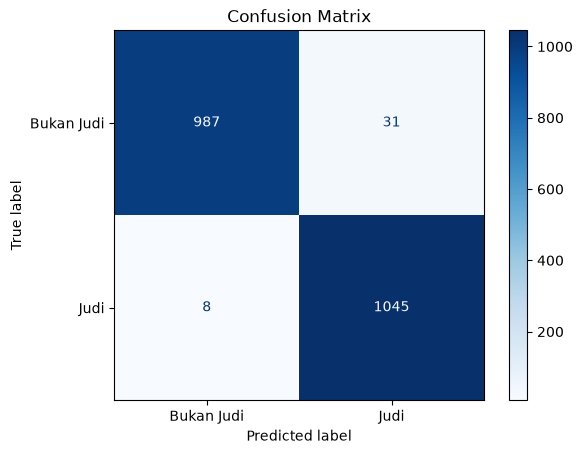

In [16]:
cm = confusion_matrix(
    true_labels,
    predictions
)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm,

    display_labels=[

        "Bukan Judi",

        "Judi"

    ]

)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")

plt.savefig(
    "../output/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
metrics = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Value":[

        accuracy,

        precision,

        recall,

        f1

    ]

})

metrics.to_csv(

    "../output/evaluation_metrics.csv",

    index=False

)

metrics

,Metric,Value
0,Accuracy,0.981169
1,Precision,0.971190
2,Recall,0.992403
3,F1 Score,0.981682


In [18]:
result = pd.DataFrame({

    "Text": test_df["hasil_preprocessing"].values,

    "Actual": true_labels,

    "Prediction": predictions

})

result.to_csv(

    "../output/prediction_result.csv",

    index=False,

    encoding="utf-8-sig"

)

result.head(20)

,Text,Actual,Prediction
0,goblok lambat sekali menyimpulkan,0,0
1,iklan yang sulit di skip ilkan sze empeshop,0,0
2,kompolnas itu singkatan dari komplotan orang l...,0,0
3,bertahanlah sedikit lebih lama,0,0
4,jepey trs tiap hari cuma di sgi88,1,1
5,untuk apa merek indonesia tapi harga ga jauh b...,0,0
6,trending brp kemaren ya,0,0
7,kalau vloger makan jaman dulu di saat lidah me...,0,0
8,junior88 always on point,1,1
9,23 14 tepe anyink,0,0
